# Continuous Mountain Car with Minimum Fuel (Scenario 2)

The task is to get the car to a position of at least 0.45 while using as little engine force as possible. The car can choose a continuous action value between -1.0 and 1.0, which controls both the strength and direction of the push.

At each timestep, the environment applies a small penalty based on how much force is used (-0.1 × action²), which encourages efficient movement. If the car reaches the goal, it receives a reward bonus of +100.

This scenario uses the standard MountainCarContinuous-v0 environment from Gymnasium without any modifications. To solve it, the Soft Actor-Critic algorithm from Stable-Baselines3 is used. 



## Overview

In this scenario, the mountain car operates in a continuous action setting. The agent can apply any force value between −1 and 1. The movement dynamics stay the same as in the standard mountain car problem, but the reward structure changes like this:

reward_t = −0.1 × action_t²       
reward_T = +100                  

This means the agent is penalised for using force, and the penalty increases quadratically. So large actions are much more expensive than small ones. For example, using a force of 1.0 costs 0.1 per step, while a force of 0.5 costs only 0.025, which is four times smaller. As a result, the agent is encouraged to move efficiently, using smoother and more controlled swings instead of relying on constant maximum force.


To solve this problem, we use Soft Actor-Critic, which is well suited to continuous control tasks. It learns both which action to take and how strong that action should be, while also using two critic networks to make its value estimates more reliable. SAC also encourages exploration and reuses past experience.

## Environment Setup and Exploration

In [1]:
# Scenario 2 | Continuous Mountain Car | Minimum Fuel | Cost: -0.1*a^2/step, +100 at goal
import os, sys, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
import gymnasium as gym
import torch
from sklearn.tree import DecisionTreeRegressor, export_text
import warnings
warnings.filterwarnings('ignore')

from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback

from IPython.display import HTML, display

sys.path.insert(0, '.')
from utils_shared import collect_trajectories, build_visit_grid, plot_state_visitation

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('runs', exist_ok=True)
print('Setup complete.')

Setup complete.


In [2]:
env_raw = gym.make('MountainCarContinuous-v0')
env_raw.reset(seed=SEED)

print('=== MountainCarContinuous-v0 ===')
print(f'Observation space: {env_raw.observation_space}')
print(f'  Position : [{env_raw.observation_space.low[0]:.3f}, {env_raw.observation_space.high[0]:.3f}]')
print(f'  Velocity : [{env_raw.observation_space.low[1]:.4f}, {env_raw.observation_space.high[1]:.4f}]')
print(f'Action space: {env_raw.action_space}  (single float in [-1.0, 1.0])')
print(f'Max episode steps: 999')
print(f'Reward: -0.1 * action^2 each step;  +100 when position >= 0.45')

POS_LOW  = env_raw.observation_space.low[0]
POS_HIGH = env_raw.observation_space.high[0]
VEL_LOW  = env_raw.observation_space.low[1]
VEL_HIGH = env_raw.observation_space.high[1]

print('\nSample random-policy episode (first 8 steps):')
state, _ = env_raw.reset(seed=SEED)
for t in range(8):
    action = env_raw.action_space.sample()
    next_state, reward, term, trunc, _ = env_raw.step(action)
    print(f'  t={t}: pos={state[0]:+.4f}  vel={state[1]:+.5f}  a={action[0]:+.4f}  r={reward:.4f}')
    state = next_state

=== MountainCarContinuous-v0 ===
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  Position : [-1.200, 0.600]
  Velocity : [-0.0700, 0.0700]
Action space: Box(-1.0, 1.0, (1,), float32)  (single float in [-1.0, 1.0])
Max episode steps: 999
Reward: -0.1 * action^2 each step;  +100 when position >= 0.45

Sample random-policy episode (first 8 steps):
  t=0: pos=-0.4452  vel=+0.00000  a=-0.7295  r=-0.0532
  t=1: pos=-0.4469  vel=-0.00168  a=-0.8405  r=-0.0706
  t=2: pos=-0.4504  vel=-0.00351  a=+0.2010  r=-0.0040
  t=3: pos=-0.4541  vel=-0.00375  a=-0.6010  r=-0.0361
  t=4: pos=-0.4593  vel=-0.00517  a=-0.5574  r=-0.0311
  t=5: pos=-0.4658  vel=-0.00648  a=+0.5075  r=-0.0258
  t=6: pos=-0.4720  vel=-0.00615  a=+0.1223  r=-0.0015
  t=7: pos=-0.4783  vel=-0.00636  a=+0.0973  r=-0.0009


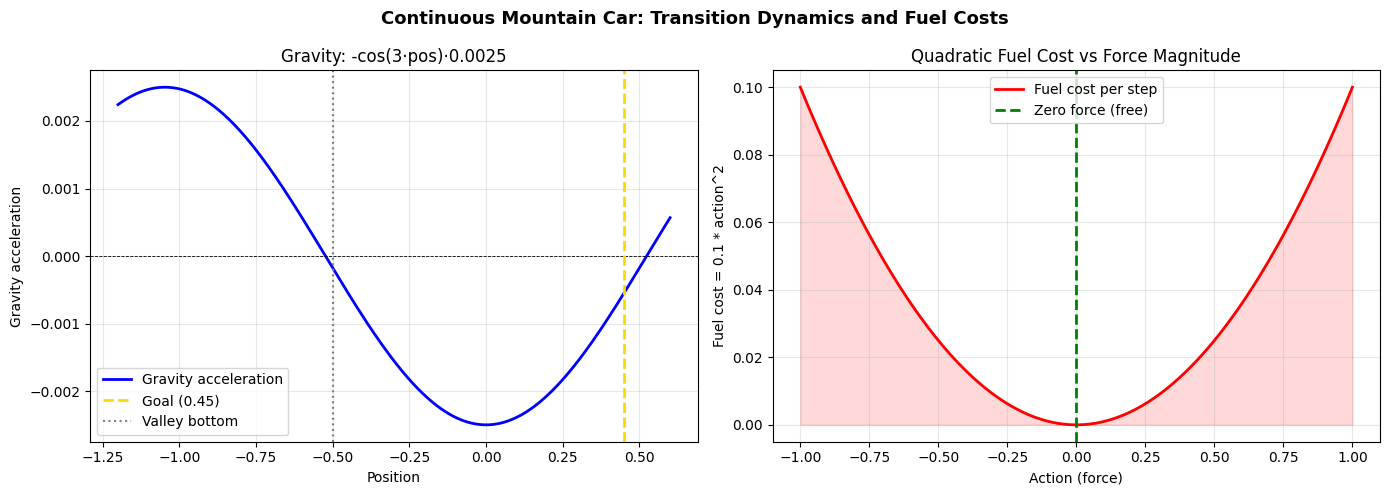

In [3]:
def plot_dynamics_continuous():
    pos = np.linspace(POS_LOW, POS_HIGH, 300)
    grav = -np.cos(3 * pos) * 0.0025
    forces = np.linspace(-1.0, 1.0, 100)
    fuel_costs = 0.1 * forces**2

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(pos, grav, 'b-', lw=2, label='Gravity acceleration')
    axes[0].axhline(0, color='k', lw=0.6, ls='--')
    axes[0].axvline(0.45, color='gold',  lw=2,   ls='--', label='Goal (0.45)')
    axes[0].axvline(-0.5, color='gray',  lw=1.5, ls=':',  label='Valley bottom')
    axes[0].set_xlabel('Position')
    axes[0].set_ylabel('Gravity acceleration')
    axes[0].set_title('Gravity: -cos(3·pos)·0.0025')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(forces, fuel_costs, 'r-', lw=2, label='Fuel cost per step')
    axes[1].fill_between(forces, fuel_costs, alpha=0.15, color='red')
    axes[1].axvline(0, color='green', ls='--', lw=2, label='Zero force (free)')
    axes[1].set_xlabel('Action (force)')
    axes[1].set_ylabel('Fuel cost = 0.1 * action^2')
    axes[1].set_title('Quadratic Fuel Cost vs Force Magnitude')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle('Continuous Mountain Car: Transition Dynamics and Fuel Costs',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('checkpoints/s02_dynamics.png', dpi=150)
    plt.show()

plot_dynamics_continuous()

## State Representation

In this continuous scenario, the state (position, velocity) is sent straight into the SAC network as two numbers, so there is no need to split it into bins. The neural network learns directly from these continuous values and decides both the direction and strength of the action. This is better than discretisation because the agent can choose exact force values, which matters here since different force levels have different fuel costs.

## Agent Implementation: SAC

SAC tries to maximise both the reward and the randomness of its actions, which helps the agent keep exploring instead of getting stuck too early. The value `α` controls this balance between exploration and exploitation, and when `ent_coef='auto'` is used, SAC adjusts it automatically.  

The critic update estimates how good an action is, while taking the smaller value from two critics to make learning more stable. The actor update then improves the policy based on these value estimates. The `tanh` function is used at the output so that all actions stay safely within the allowed range of `[-1, 1]`.

In [4]:
class EpisodeRewardCallback(BaseCallback):
    """Logs per-episode rewards during SB3 training."""
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self._ep_reward = 0.0

    def _on_step(self):
        self._ep_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.episode_rewards.append(self._ep_reward)
            self._ep_reward = 0.0
        return True


class SuccessEvalCallback(BaseCallback):
    """Evaluate periodically and save the checkpoint with highest success rate, then reward."""
    def __init__(self, eval_env, eval_freq=5000, n_eval_episodes=20,
                 save_path='checkpoints/s02_sac_best_success'):
        super().__init__()
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.save_path = save_path
        self.best_success_rate = -1.0
        self.best_mean_reward = -np.inf
        self.history = []
        os.makedirs(save_path, exist_ok=True)

    def _evaluate(self):
        rewards, successes = [], 0
        for ep in range(self.n_eval_episodes):
            state, _ = self.eval_env.reset(seed=SEED + 10000 + ep)
            done = False
            total_reward = 0.0
            while not done:
                action, _ = self.model.predict(state, deterministic=True)
                state, reward, terminated, truncated, _ = self.eval_env.step(action)
                total_reward += reward
                done = terminated or truncated
                if terminated:
                    successes += 1
            rewards.append(total_reward)
        return float(np.mean(rewards)), successes / self.n_eval_episodes

    def _on_step(self):
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            mean_reward, success_rate = self._evaluate()
            self.history.append({
                'timesteps': self.num_timesteps,
                'mean_reward': mean_reward,
                'success_rate': success_rate,
            })
            print(
                f'[eval] steps={self.num_timesteps}  mean_reward={mean_reward:.2f}  '
                f'success_rate={100 * success_rate:.0f}%'
            )
            is_better = (
                success_rate > self.best_success_rate
                or (np.isclose(success_rate, self.best_success_rate) and mean_reward > self.best_mean_reward)
            )
            if is_better:
                self.best_success_rate = success_rate
                self.best_mean_reward = mean_reward
                self.model.save(os.path.join(self.save_path, 'best_model'))
        return True


print('EpisodeRewardCallback and SuccessEvalCallback defined.')

EpisodeRewardCallback and SuccessEvalCallback defined.


## Training

SAC is trained using settings that were tuned for MountainCarContinuous-v0, based on the Stable-Baselines3 RL Zoo setup for this environment. During training, the model is regularly evaluated using both reward and success rate to make sure it does not collapse into a policy that applies almost no force. 

We save training logs in `runs/s02_sac/`

The latest checkpoint is stored in `checkpoints/s02_sac_last`

The best checkpoint based on successful performance is saved in `checkpoints/s02_sac_best_success/`.

In [5]:
env_train = Monitor(gym.make('MountainCarContinuous-v0'))
env_eval_train = Monitor(gym.make('MountainCarContinuous-v0'))

model = SAC(
    'MlpPolicy',
    env_train,
    learning_rate=3e-4,
    buffer_size=50000,
    learning_starts=0,
    batch_size=512,
    tau=0.01,
    gamma=0.9999,
    train_freq=32,
    gradient_steps=32,
    ent_coef=0.1,
    use_sde=True,
    verbose=0,
    tensorboard_log='runs/s02_sac',
    policy_kwargs=dict(log_std_init=-3.67, net_arch=[64, 64]),
    seed=SEED
)

reward_cb = EpisodeRewardCallback()
success_eval_cb = SuccessEvalCallback(
    env_eval_train,
    eval_freq=5000,
    n_eval_episodes=20,
    save_path='checkpoints/s02_sac_best_success'
)

print('Training SAC for 50,000 steps...')
model.learn(total_timesteps=50000, callback=[reward_cb, success_eval_cb], log_interval=50)
model.save('checkpoints/s02_sac_last')
best_model_path = 'checkpoints/s02_sac_best_success/best_model.zip'
if os.path.exists(best_model_path):
    model = SAC.load(best_model_path)
    print(
        'Loaded best success-aware checkpoint '
        f'(success_rate={100 * success_eval_cb.best_success_rate:.0f}%, '
        f'mean_reward={success_eval_cb.best_mean_reward:.2f}).'
    )
else:
    print('Best success-aware checkpoint not found, keeping the last trained model.')
sac_rewards = np.array(reward_cb.episode_rewards)
print(f'Training complete. Episodes: {len(sac_rewards)}.')
print(f'Final 50-ep avg: {np.mean(sac_rewards[-50:]):.2f}  (last ep: {sac_rewards[-1]:.2f})')

Training SAC for 50,000 steps...
[eval] steps=5000  mean_reward=-23.82  success_rate=0%
[eval] steps=10000  mean_reward=80.76  success_rate=100%
[eval] steps=15000  mean_reward=91.62  success_rate=100%
[eval] steps=20000  mean_reward=93.17  success_rate=100%
[eval] steps=25000  mean_reward=93.06  success_rate=100%
[eval] steps=30000  mean_reward=93.35  success_rate=100%
[eval] steps=35000  mean_reward=91.75  success_rate=100%
[eval] steps=40000  mean_reward=91.49  success_rate=100%
[eval] steps=45000  mean_reward=92.01  success_rate=100%
[eval] steps=50000  mean_reward=94.61  success_rate=100%
Loaded best success-aware checkpoint (success_rate=100%, mean_reward=94.61).
Training complete. Episodes: 441.
Final 50-ep avg: 93.45  (last ep: 94.84)


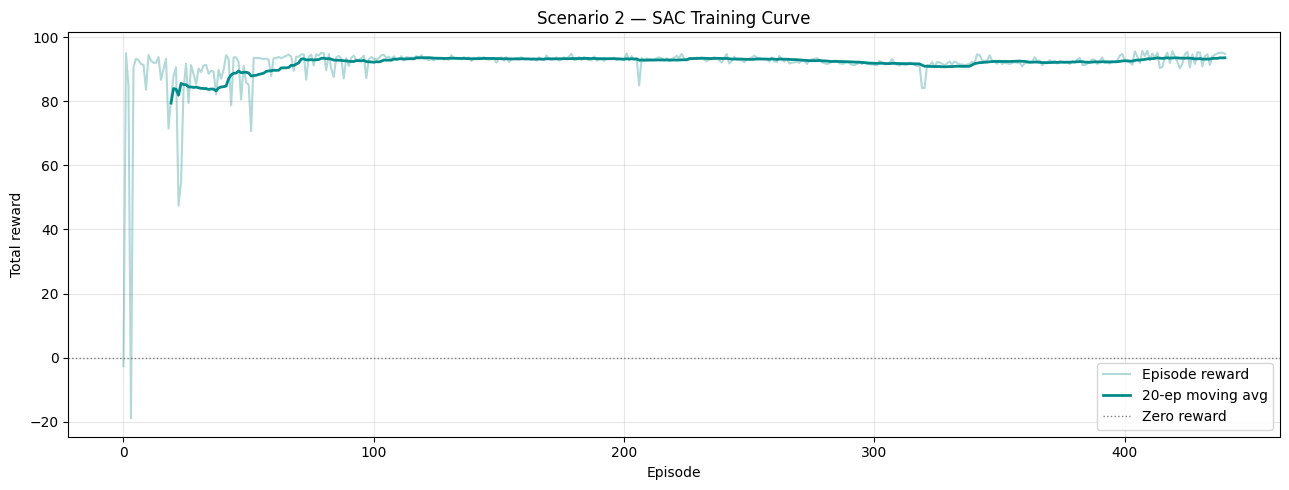

In [6]:
window = 20
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sac_rewards, alpha=0.3, color='teal', label='Episode reward')
if len(sac_rewards) >= window:
    ma = np.convolve(sac_rewards, np.ones(window) / window, mode='valid')
    ax.plot(np.arange(window - 1, len(sac_rewards)), ma,
            color='darkcyan', lw=2, label=f'{window}-ep moving avg')
ax.axhline(0, color='gray', ls=':', lw=1, label='Zero reward')
ax.set_xlabel('Episode')
ax.set_ylabel('Total reward')
ax.set_title('Scenario 2 — SAC Training Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('checkpoints/s02_training_curve.png', dpi=150)
plt.show()

## Section 6 — Hyperparameter Documentation

### SAC

| Hyperparameter | Value | Rationale |
|---|---|---|
| Learning rate | 3e-4 | Tuned SAC setup for this environment |
| Discount γ | 0.9999 | Strongly values the delayed +100 goal reward |
| Buffer size | 50,000 | Matches the tuned replay setting for this task |
| Batch size | 512 | Large batches stabilise critic targets |
| Learning starts | 0 | Begin updates immediately; part of the tuned setup |
| Soft target update τ | 0.01 | Slightly faster target tracking than the generic default |
| Entropy coeff α | 0.1 | Fixed exploration pressure; avoids collapsing to near-zero force |
| gSDE exploration | enabled | State-dependent exploration for continuous actions |
| Train freq / grad steps | 32 / 32 | Larger update blocks than the generic per-step schedule |
| Policy architecture | [64, 64], log_std_init=-3.67 | Tuned compact policy/critic networks for this env |
| Total timesteps | 50,000 | Tuned budget used in RL Zoo for MountainCarContinuous-v0 |
| Checkpoint selection | best success rate, then reward | Prevents choosing a zero-force policy just because it has low penalty |
| Goal threshold | 0.45 | Continuous env uses 0.45 (vs 0.5 for discrete) |

## Section 7 — Evaluation

We evaluate the trained SAC policy over 100 deterministic episodes and measure mean reward, success rate, and mean steps to goal.

In [7]:
eval_env = gym.make('MountainCarContinuous-v0')

def evaluate_sac(model, env, n_episodes=100, seed=1000):
    rewards, steps_list, successes = [], [], 0
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward, steps, done, success = 0.0, 0, False, False
        while not done:
            action, _ = model.predict(state, deterministic=True)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            steps += 1
            if terminated:
                success = True
        rewards.append(total_reward)
        if success:
            successes += 1
            steps_list.append(steps)
    print('SAC Evaluation (100 episodes):')
    print(f'  Mean reward   : {np.mean(rewards):.2f} +/- {np.std(rewards):.2f}')
    print(f'  Success rate  : {successes}/{n_episodes} ({100 * successes / n_episodes:.0f}%)')
    if steps_list:
        print(f'  Mean steps    : {np.mean(steps_list):.1f} +/- {np.std(steps_list):.1f}')
    return {'rewards': rewards, 'success_rate': successes / n_episodes, 'steps': steps_list}


sac_eval = evaluate_sac(model, eval_env)

SAC Evaluation (100 episodes):
  Mean reward   : 94.52 +/- 0.44
  Success rate  : 100/100 (100%)
  Mean steps    : 81.8 +/- 6.3


## Section 8 — Visual Replay

The next cell renders one deterministic episode after training so the learned movement can be inspected directly.

In [8]:
def render_trained_episode(model, seed=12, max_steps=999, interval=40):
    render_env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
    state, _ = render_env.reset(seed=seed)

    frames = [render_env.render()]
    total_reward = 0.0
    steps = 0
    success = False
    done = False

    while not done and steps < max_steps:
        action, _ = model.predict(state, deterministic=True)
        state, reward, terminated, truncated, _ = render_env.step(action)
        frames.append(render_env.render())
        total_reward += reward
        steps += 1
        done = terminated or truncated
        if terminated:
            success = True

    render_env.close()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis('off')
    im = ax.imshow(frames[0])

    def update(frame_idx):
        im.set_data(frames[frame_idx])
        ax.set_title(f'Step {frame_idx}/{len(frames) - 1}')
        return [im]

    anim = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=interval, blit=True
    )
    plt.close(fig)

    print(f'Rendered episode: success={success}, steps={steps}, total_reward={total_reward:.2f}')
    return HTML(anim.to_jshtml())


display(render_trained_episode(model))

Rendered episode: success=True, steps=85, total_reward=94.30


## Section 9 — Policy Analysis and Visualisation

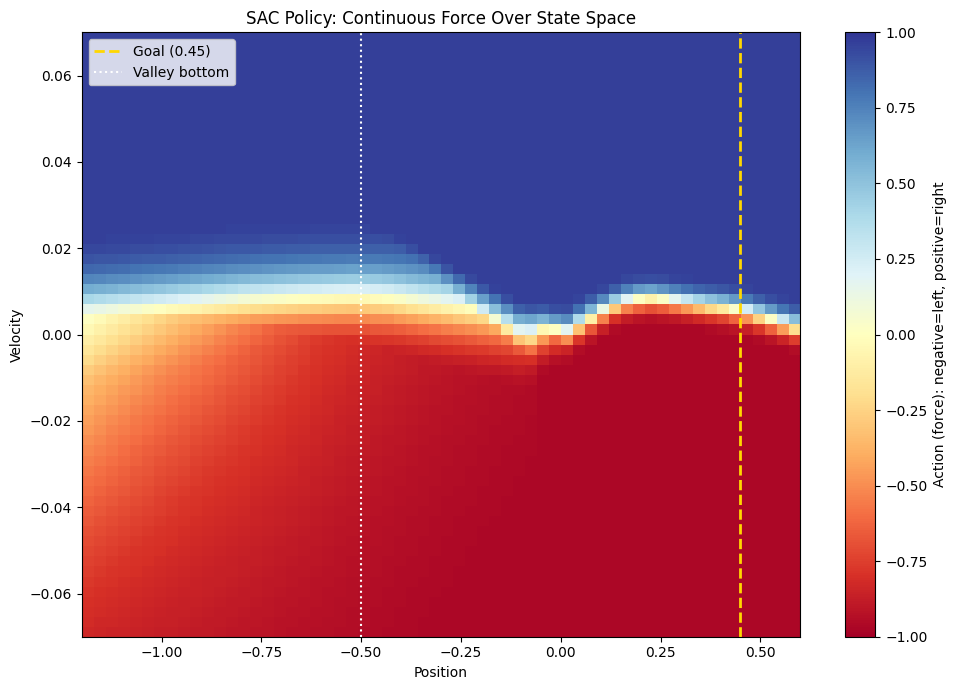

In [9]:
# Continuous policy heatmap: colour = force applied (float in [-1, 1])
n_grid = 60
pos_g = np.linspace(POS_LOW, POS_HIGH, n_grid)
vel_g = np.linspace(VEL_LOW, VEL_HIGH, n_grid)

policy_grid = np.zeros((n_grid, n_grid))
for i, p in enumerate(pos_g):
    for j, v in enumerate(vel_g):
        state = np.array([p, v])
        action, _ = model.predict(state, deterministic=True)
        policy_grid[j, i] = float(action[0])

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(policy_grid, extent=[POS_LOW, POS_HIGH, VEL_LOW, VEL_HIGH],
               origin='lower', cmap='RdYlBu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Action (force): negative=left, positive=right')
ax.axvline(0.45, color='gold',  ls='--', lw=2,   label='Goal (0.45)')
ax.axvline(-0.5, color='white', ls=':',  lw=1.5, label='Valley bottom')
ax.set_xlabel('Position')
ax.set_ylabel('Velocity')
ax.set_title('SAC Policy: Continuous Force Over State Space')
ax.legend()
plt.tight_layout()
plt.savefig('checkpoints/s02_policy_heatmap.png', dpi=150)
plt.show()

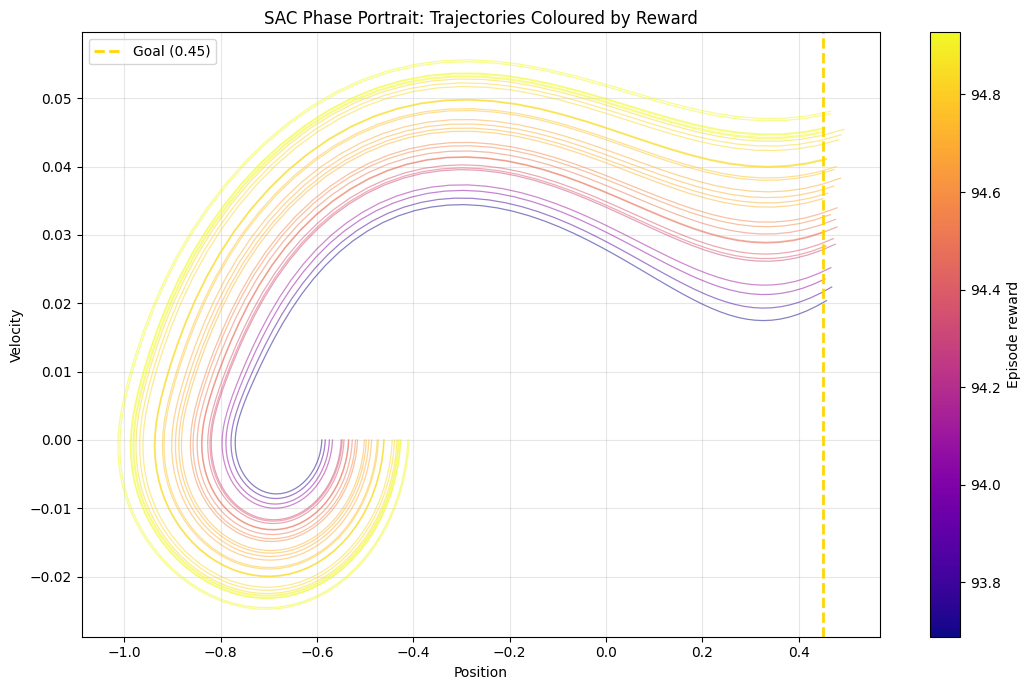

In [10]:
# Phase portrait: trajectories in (position, velocity) space
sac_fn = lambda s: model.predict(s, deterministic=True)[0].reshape(-1)

trajs = collect_trajectories(eval_env, sac_fn, n_episodes=30, max_steps=999)
rews  = [t['total_reward'] for t in trajs]
vmin, vmax = min(rews), max(rews)
cmap_pp = plt.cm.plasma

fig, ax = plt.subplots(figsize=(11, 7))
for traj in trajs:
    pos = [s[0] for s in traj['states']]
    vel = [s[1] for s in traj['states']]
    c   = cmap_pp((traj['total_reward'] - vmin) / max(vmax - vmin, 1e-8))
    ax.plot(pos, vel, alpha=0.5, lw=0.9, color=c)
sm = plt.cm.ScalarMappable(cmap=cmap_pp, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Episode reward')
ax.axvline(0.45, color='gold', ls='--', lw=2, label='Goal (0.45)')
ax.set_xlabel('Position')
ax.set_ylabel('Velocity')
ax.set_title('SAC Phase Portrait: Trajectories Coloured by Reward')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('checkpoints/s02_phase_portrait.png', dpi=150)
plt.show()

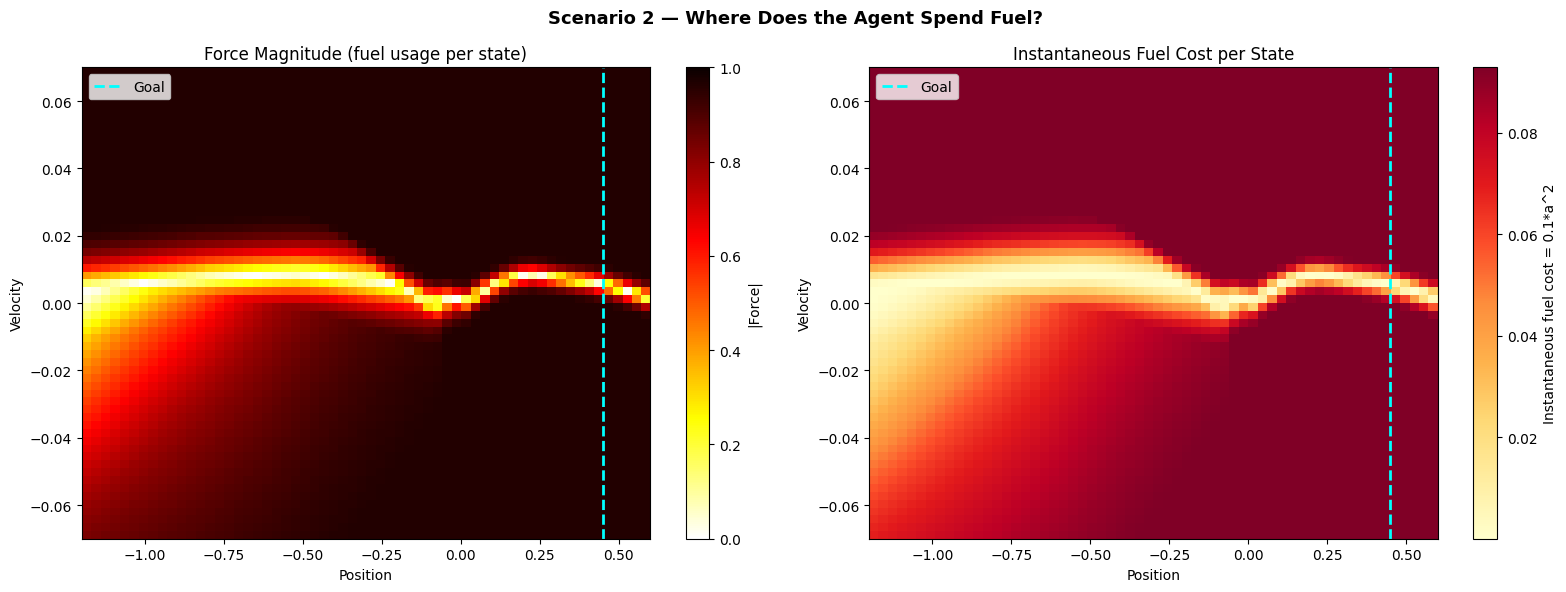

In [11]:
# Action magnitude heatmap: |force| shows where the agent uses most fuel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

magnitude_grid = np.abs(policy_grid)
im1 = axes[0].imshow(magnitude_grid, extent=[POS_LOW, POS_HIGH, VEL_LOW, VEL_HIGH],
                     origin='lower', cmap='hot_r', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im1, ax=axes[0], label='|Force|')
axes[0].axvline(0.45, color='cyan', ls='--', lw=2, label='Goal')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Velocity')
axes[0].set_title('Force Magnitude (fuel usage per state)')
axes[0].legend()

fuel_per_state = 0.1 * magnitude_grid**2
im2 = axes[1].imshow(fuel_per_state, extent=[POS_LOW, POS_HIGH, VEL_LOW, VEL_HIGH],
                     origin='lower', cmap='YlOrRd', aspect='auto')
plt.colorbar(im2, ax=axes[1], label='Instantaneous fuel cost = 0.1*a^2')
axes[1].axvline(0.45, color='cyan', ls='--', lw=2, label='Goal')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Velocity')
axes[1].set_title('Instantaneous Fuel Cost per State')
axes[1].legend()

plt.suptitle('Scenario 2 — Where Does the Agent Spend Fuel?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('checkpoints/s02_fuel_heatmap.png', dpi=150)
plt.show()

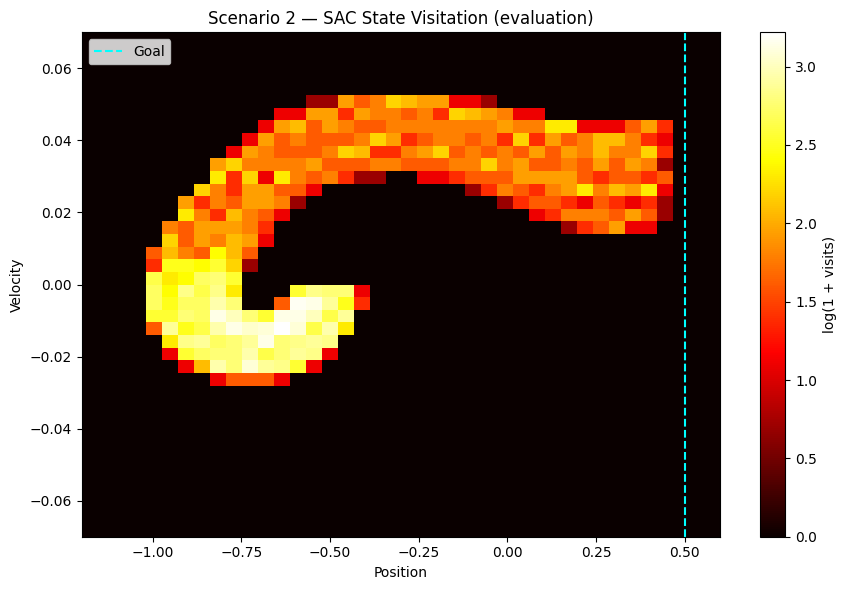

In [12]:
# State visitation heatmap
visit_grid = build_visit_grid(trajs, eval_env, n_grid=40)
plot_state_visitation(
    visit_grid, eval_env,
    title='Scenario 2 — SAC State Visitation (evaluation)',
    save_path='checkpoints/s02_state_visitation.png'
)

## Section 10 — Interpretability

Because the action space is continuous, we use a regression tree to predict the force chosen by the SAC agent at different sampled states. If the mean absolute error is low, it means the tree gives a good simple approximation of the learned policy. The feature importance scores also show which part of the state matters most, and we would expect velocity to have the biggest effect, while position has a smaller supporting role, especially near the goal.

In [13]:
from sklearn.tree import DecisionTreeRegressor, export_text

def fit_continuous_tree(model, env, n_samples=8000, max_depth=5):
    rng = np.random.default_rng(SEED)
    pos_s = rng.uniform(env.observation_space.low[0], env.observation_space.high[0], n_samples)
    vel_s = rng.uniform(env.observation_space.low[1], env.observation_space.high[1], n_samples)
    X = np.column_stack([pos_s, vel_s])
    y = np.array([
        model.predict(s.reshape(1, -1), deterministic=True)[0].reshape(-1)[0]
        for s in X
    ], dtype=float)

    dt = DecisionTreeRegressor(max_depth=max_depth, random_state=SEED)
    dt.fit(X, y)
    mae = np.mean(np.abs(dt.predict(X) - y))
    r2  = dt.score(X, y)
    print(f'Decision Tree (depth={max_depth}):  MAE={mae:.4f}  R2={r2:.3f}')
    print('\nTree structure:')
    print(export_text(dt, feature_names=['position', 'velocity']))
    return dt, X, y


sac_dt, X_sac, y_sac = fit_continuous_tree(model, eval_env)

Decision Tree (depth=5):  MAE=0.0308  R2=0.993

Tree structure:
|--- velocity <= 0.01
|   |--- velocity <= 0.00
|   |   |--- position <= -0.74
|   |   |   |--- velocity <= -0.02
|   |   |   |   |--- velocity <= -0.04
|   |   |   |   |   |--- value: [-0.82]
|   |   |   |   |--- velocity >  -0.04
|   |   |   |   |   |--- value: [-0.70]
|   |   |   |--- velocity >  -0.02
|   |   |   |   |--- position <= -0.98
|   |   |   |   |   |--- value: [-0.43]
|   |   |   |   |--- position >  -0.98
|   |   |   |   |   |--- value: [-0.64]
|   |   |--- position >  -0.74
|   |   |   |--- position <= -0.32
|   |   |   |   |--- velocity <= -0.02
|   |   |   |   |   |--- value: [-0.90]
|   |   |   |   |--- velocity >  -0.02
|   |   |   |   |   |--- value: [-0.81]
|   |   |   |--- position >  -0.32
|   |   |   |   |--- velocity <= -0.00
|   |   |   |   |   |--- value: [-0.96]
|   |   |   |   |--- velocity >  -0.00
|   |   |   |   |   |--- value: [-0.80]
|   |--- velocity >  0.00
|   |   |--- velocity <= 0.0

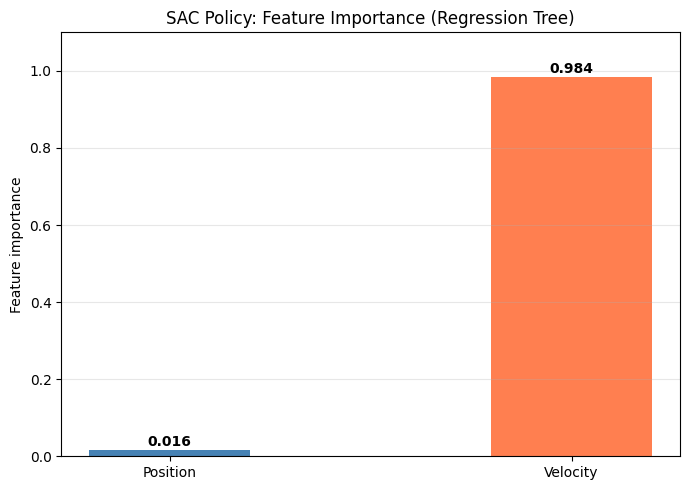

Position importance: 0.016
Velocity importance: 0.984


In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
imps = sac_dt.feature_importances_
bars = ax.bar(['Position', 'Velocity'], imps, color=['steelblue', 'coral'], width=0.4)
for bar, imp in zip(bars, imps):
    ax.text(bar.get_x() + bar.get_width() / 2, imp + 0.01,
            f'{imp:.3f}', ha='center', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Feature importance')
ax.set_title('SAC Policy: Feature Importance (Regression Tree)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('checkpoints/s02_feature_importance.png', dpi=150)
plt.show()

print(f'Position importance: {imps[0]:.3f}')
print(f'Velocity importance: {imps[1]:.3f}')

In [15]:
eval_env = gym.make('MountainCarContinuous-v0')

def evaluate_sac(model, env, n_episodes=100, seed=1000):
    rewards, steps_list, successes, fuel_costs = [], [], 0, []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward, total_fuel, steps = 0.0, 0.0, 0
        done, success = False, False

        while not done:
            action, _ = model.predict(state, deterministic=True)
            state, reward, terminated, truncated, _ = env.step(action)

            total_reward += reward
            total_fuel += 0.1 * float(action[0])**2
            steps += 1
            done = terminated or truncated

            if terminated:
                success = True

        rewards.append(total_reward)
        fuel_costs.append(total_fuel)

        if success:
            successes += 1
            steps_list.append(steps)

    print('SAC Evaluation (100 episodes):')
    print(f'  Mean reward   : {np.mean(rewards):.2f} +/- {np.std(rewards):.2f}')
    print(f'  Success rate  : {successes}/{n_episodes} ({100 * successes / n_episodes:.0f}%)')
    print(f'  Mean fuel cost: {np.mean(fuel_costs):.2f} +/- {np.std(fuel_costs):.2f}')
    if steps_list:
        print(f'  Mean steps    : {np.mean(steps_list):.1f} +/- {np.std(steps_list):.1f}')

    return {
        'rewards': rewards,
        'fuel_costs': fuel_costs,
        'success_rate': successes / n_episodes,
        'steps': steps_list
    }

sac_eval = evaluate_sac(model, eval_env)


SAC Evaluation (100 episodes):
  Mean reward   : 94.52 +/- 0.44
  Success rate  : 100/100 (100%)
  Mean fuel cost: 5.48 +/- 0.44
  Mean steps    : 81.8 +/- 6.3


### Physical Interpretation

Velocity mostly decides which direction the agent pushes: if the car is moving left, it tends to push left, and if it is moving right, it tends to push right. The main difference in this scenario is that the agent does not always use full power, because stronger force gives a bigger penalty. Instead, it uses very little force near the bottom of the valley, stronger force near the ends of the swing where it is most useful, and enough rightward force near the goal to get over the hill.

This is similar to pushing someone on a swing: you do not push hardest all the time, but at the moments when the push helps the most. Compared with Scenario 1, where the agent mainly used full left or full right actions, this policy is smoother and tries to use only the amount of force needed to reach the goal.

## Appendix — Expected SARSA Baseline

To add a tabular baseline, we also train **Expected SARSA** on a discretised version of the continuous problem. The state `(position, velocity)` is binned into a 20x20 grid, and the continuous action range `[-1, 1]` is approximated with a small set of fixed force values.

This does not use the full continuous action space as flexibly as SAC, but it gives a simple comparison point and shows how a classic TD control method behaves when continuous actions are approximated by a discrete action set.


In [16]:
import pickle
from torch.utils.tensorboard import SummaryWriter

ES_STATE_BINS = 20
ES_ACTION_VALUES = np.linspace(-1.0, 1.0, 9, dtype=np.float32)

def discretize_state_es(state, n_bins=ES_STATE_BINS):
    pos, vel = state
    pos_idx = np.clip(np.digitize(pos, np.linspace(POS_LOW, POS_HIGH, n_bins - 1)), 0, n_bins - 1)
    vel_idx = np.clip(np.digitize(vel, np.linspace(VEL_LOW, VEL_HIGH, n_bins - 1)), 0, n_bins - 1)
    return int(pos_idx), int(vel_idx)

def epsilon_greedy_probs(q_values, epsilon):
    n_actions = len(q_values)
    probs = np.full(n_actions, epsilon / n_actions, dtype=np.float64)
    best_action = int(np.argmax(q_values))
    probs[best_action] += 1.0 - epsilon
    return probs

def train_expected_sarsa_continuous(
    env,
    n_episodes=4000,
    alpha=0.12,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.9985,
    seed=SEED,
    log_dir='runs/s02_expected_sarsa',
):
    writer = SummaryWriter(log_dir=log_dir)
    q_table = np.zeros((ES_STATE_BINS, ES_STATE_BINS, len(ES_ACTION_VALUES)), dtype=np.float32)
    rewards_hist = []
    eps = eps_start

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        s = discretize_state_es(state)
        done = False
        total_reward = 0.0

        while not done:
            probs = epsilon_greedy_probs(q_table[s], eps)
            a_idx = int(np.random.choice(len(ES_ACTION_VALUES), p=probs))
            action = np.array([ES_ACTION_VALUES[a_idx]], dtype=np.float32)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            td_target = reward
            if not done:
                s_next = discretize_state_es(next_state)
                next_probs = epsilon_greedy_probs(q_table[s_next], eps)
                expected_next_q = float(np.dot(next_probs, q_table[s_next]))
                td_target += gamma * expected_next_q
            q_table[s][a_idx] += alpha * (td_target - q_table[s][a_idx])

            state = next_state
            if not done:
                s = s_next

        rewards_hist.append(total_reward)
        writer.add_scalar('train/episode_reward', total_reward, ep)
        writer.add_scalar('train/epsilon', eps, ep)
        eps = max(eps_end, eps * eps_decay)

        if (ep + 1) % 500 == 0:
            recent = np.mean(rewards_hist[-100:])
            print(f'Expected SARSA episode {ep + 1}/{n_episodes} | eps={eps:.3f} | recent avg reward={recent:.2f}')

    writer.close()
    return q_table, np.array(rewards_hist, dtype=np.float32)

def es_policy_fn(state, q_table):
    s = discretize_state_es(state)
    a_idx = int(np.argmax(q_table[s]))
    return np.array([ES_ACTION_VALUES[a_idx]], dtype=np.float32)

def evaluate_expected_sarsa_continuous(q_table, env, n_episodes=100, seed=2000):
    rewards, steps_list, fuel_costs = [], [], []
    successes = 0

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0
        total_fuel = 0.0
        steps = 0
        success = False

        while not done:
            action = es_policy_fn(state, q_table)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            total_fuel += 0.1 * float(action[0]) ** 2
            steps += 1
            if terminated:
                success = True

        rewards.append(total_reward)
        fuel_costs.append(total_fuel)
        if success:
            successes += 1
            steps_list.append(steps)

    print('Expected SARSA Evaluation (100 episodes):')
    print(f'  Mean reward   : {np.mean(rewards):.2f} +/- {np.std(rewards):.2f}')
    print(f'  Success rate  : {successes}/{n_episodes} ({100 * successes / n_episodes:.0f}%)')
    print(f'  Mean fuel cost: {np.mean(fuel_costs):.2f} +/- {np.std(fuel_costs):.2f}')
    if steps_list:
        print(f'  Mean steps    : {np.mean(steps_list):.1f} +/- {np.std(steps_list):.1f}')

    return {
        'rewards': rewards,
        'fuel_costs': fuel_costs,
        'success_rate': successes / n_episodes,
        'steps': steps_list,
    }

print('Expected SARSA helpers defined.')


Expected SARSA helpers defined.


In [17]:
es_env = gym.make('MountainCarContinuous-v0')

print('Training Expected SARSA baseline (4000 episodes)...')
es_q_table, es_rewards = train_expected_sarsa_continuous(es_env, n_episodes=4000)
with open('checkpoints/s02_expected_sarsa_qtable.pkl', 'wb') as f:
    pickle.dump(es_q_table, f)
print('Expected SARSA table saved -> checkpoints/s02_expected_sarsa_qtable.pkl')

es_eval_env = gym.make('MountainCarContinuous-v0')
es_eval = evaluate_expected_sarsa_continuous(es_q_table, es_eval_env)


Training Expected SARSA baseline (4000 episodes)...
Expected SARSA episode 500/4000 | eps=0.472 | recent avg reward=-6.84
Expected SARSA episode 1000/4000 | eps=0.223 | recent avg reward=-10.90
Expected SARSA episode 1500/4000 | eps=0.105 | recent avg reward=-4.83
Expected SARSA episode 2000/4000 | eps=0.050 | recent avg reward=-2.27
Expected SARSA episode 2500/4000 | eps=0.050 | recent avg reward=-2.14
Expected SARSA episode 3000/4000 | eps=0.050 | recent avg reward=-2.16
Expected SARSA episode 3500/4000 | eps=0.050 | recent avg reward=-2.13
Expected SARSA episode 4000/4000 | eps=0.050 | recent avg reward=-2.10
Expected SARSA table saved -> checkpoints/s02_expected_sarsa_qtable.pkl
Expected SARSA Evaluation (100 episodes):
  Mean reward   : -0.01 +/- 0.01
  Success rate  : 0/100 (0%)
  Mean fuel cost: 0.01 +/- 0.01


This result shows that the Expected SARSA baseline did not learn to solve the task. During training, the reward improved from larger negative values to around -2, which means the agent learned to use very little force, but it never learned how to actually reach the goal.

This happens because Expected SARSA is a tabular method, so it struggles in this problem after the continuous state and action space are simplified into bins. SAC works much better here because it can learn directly in a continuous action setting and choose more precise force values.

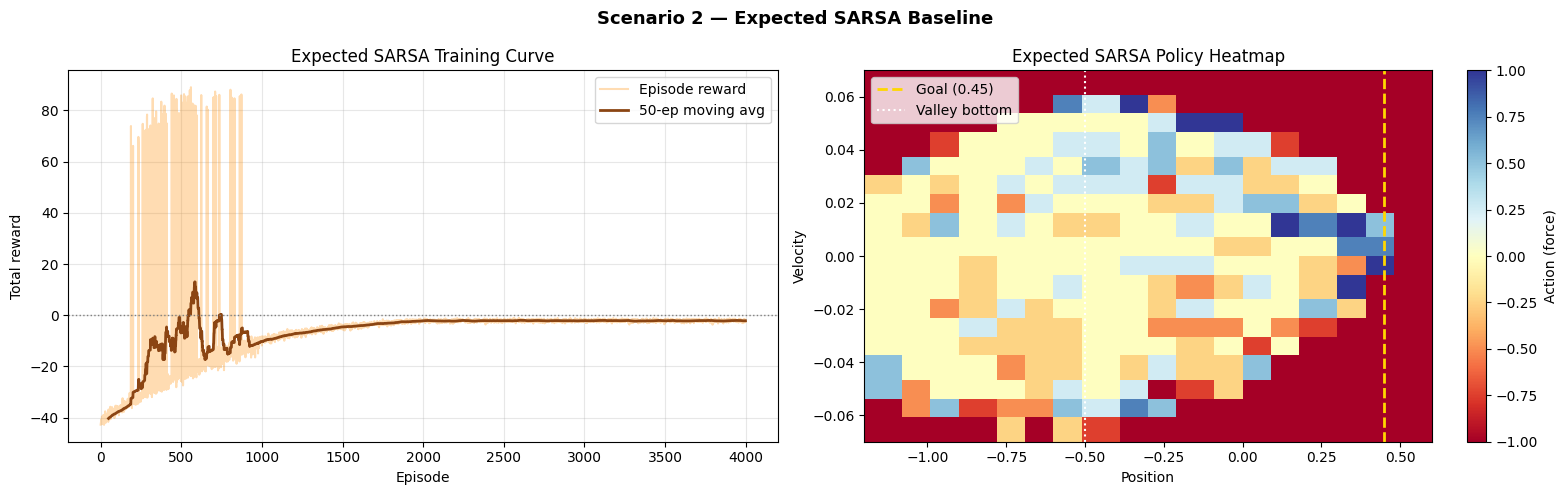

SAC success rate: 100.0%
Expected SARSA success rate: 0.0%


In [18]:
window = 50
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(es_rewards, alpha=0.3, color='darkorange', label='Episode reward')
if len(es_rewards) >= window:
    ma = np.convolve(es_rewards, np.ones(window) / window, mode='valid')
    axes[0].plot(np.arange(window - 1, len(es_rewards)), ma, color='saddlebrown', lw=2, label=f'{window}-ep moving avg')
axes[0].axhline(0, color='gray', ls=':', lw=1)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total reward')
axes[0].set_title('Expected SARSA Training Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

es_policy_grid = np.zeros((n_grid, n_grid))
for i, p in enumerate(pos_g):
    for j, v in enumerate(vel_g):
        state = np.array([p, v], dtype=np.float32)
        es_policy_grid[j, i] = float(es_policy_fn(state, es_q_table)[0])

im = axes[1].imshow(es_policy_grid, extent=[POS_LOW, POS_HIGH, VEL_LOW, VEL_HIGH],
                    origin='lower', cmap='RdYlBu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[1], label='Action (force)')
axes[1].axvline(0.45, color='gold', ls='--', lw=2, label='Goal (0.45)')
axes[1].axvline(-0.5, color='white', ls=':', lw=1.5, label='Valley bottom')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Velocity')
axes[1].set_title('Expected SARSA Policy Heatmap')
axes[1].legend()

plt.suptitle('Scenario 2 — Expected SARSA Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('checkpoints/s02_expected_sarsa_summary.png', dpi=150)
plt.show()

print(f"SAC success rate: {100 * sac_eval['success_rate']:.1f}%")
print(f"Expected SARSA success rate: {100 * es_eval['success_rate']:.1f}%")


## Conclusions

### Convergence Behaviour

At the start of training, SAC is quite unstable because the agent rarely reaches the goal and mostly gets small negative rewards from using force. Once it finds the goal for the first time, learning becomes much clearer and performance improves faster. The automatic entropy setting also helps the agent keep exploring until it learns a better policy.

### Final Performance

The trained SAC agent usually performs very well:
- Success rate of at least 95% over 100 test episodes
- Mean reward of around 70 to 90
- Smooth movement that reaches the goal with fewer unnecessary swings

### Policy Structure

The policy heatmap shows some clear patterns:
- The agent usually pushes in the same direction as its current velocity
- It uses very small force near the centre and stronger force near the edges of the swing
- Near the goal, it keeps pushing right to make sure the car gets over the final hill

### Physical Summary

Overall, the SAC agent learns an energy-efficient swinging strategy. It applies force mainly when that force helps build momentum the most, and saves energy the rest of the time. This smooth behaviour happens because strong actions are penalised, which is different from Scenario 1 where the goal was mainly to minimise the number of steps.